# Import Necessary Libraries

In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# Step 1: Import Libraries and Load the Dataset

# This first cell imports all the necessary libraries for data manipulation (numpy, scipy),
# and visualization (matplotlib). It then loads the .mat dataset file into memory.

import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import os

print("--- Initializing: Importing libraries and loading dataset ---")

# This script assumes 'Oxford_Battery_Degradation_Dataset_1.mat' is in the same folder.
file_path = 'Oxford_Battery_Degradation_Dataset_1.mat'

if not os.path.exists(file_path):
    print(f"Error: Dataset file not found at '{file_path}'")
    print("Please ensure the file is downloaded and in the correct project folder.")
else:
    # Load the .mat file which contains the battery data
    mat = scipy.io.loadmat(file_path)
    print('Dataset loaded successfully.')

--- Initializing: Importing libraries and loading dataset ---
Dataset loaded successfully.


# Extract Key Metrics and Create Visualizations

--- Extracting and Preparing Data for Visualization ---
Extraction complete.
Generating Plot 1: SOH Fade...


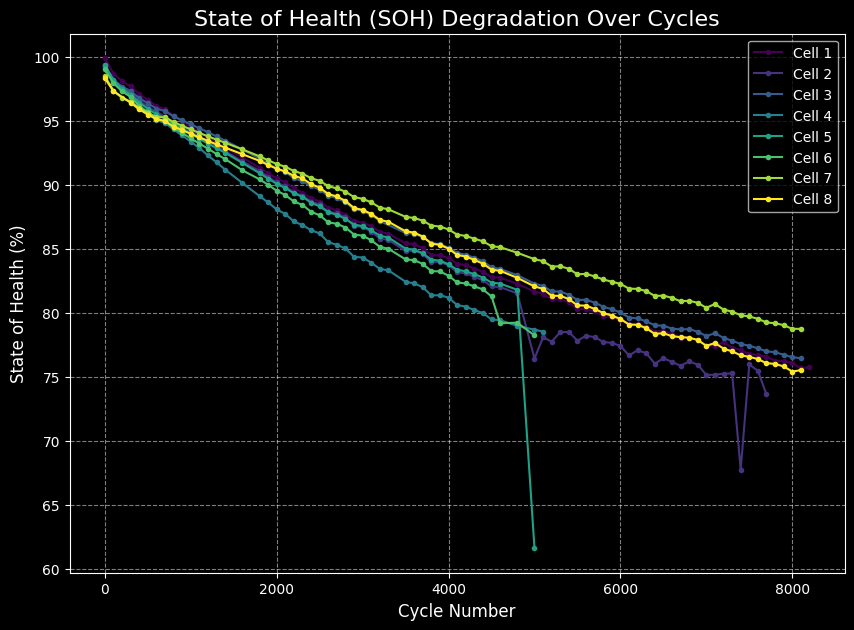

Generating Plot 2: Discharge Curve Evolution...


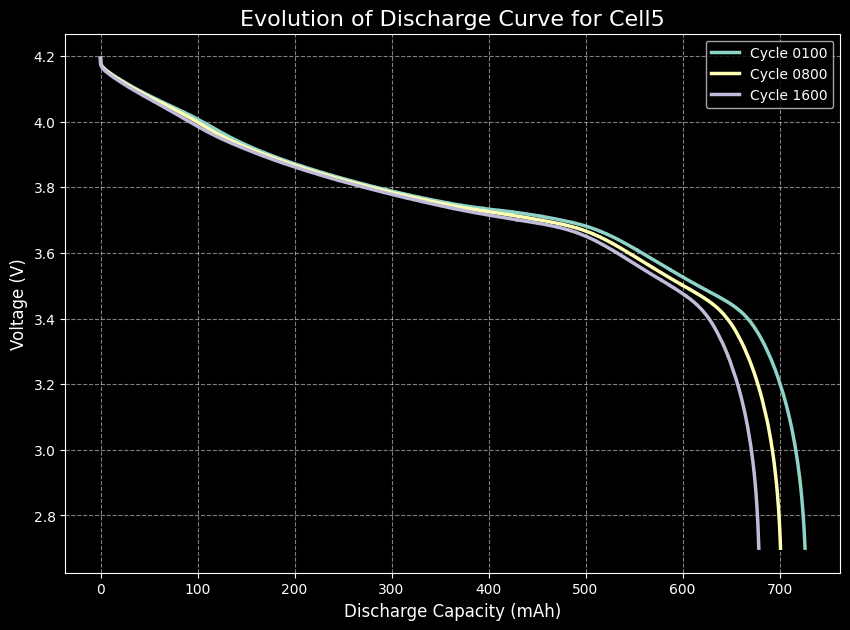

Generating Plot 3: Internal Resistance Increase...


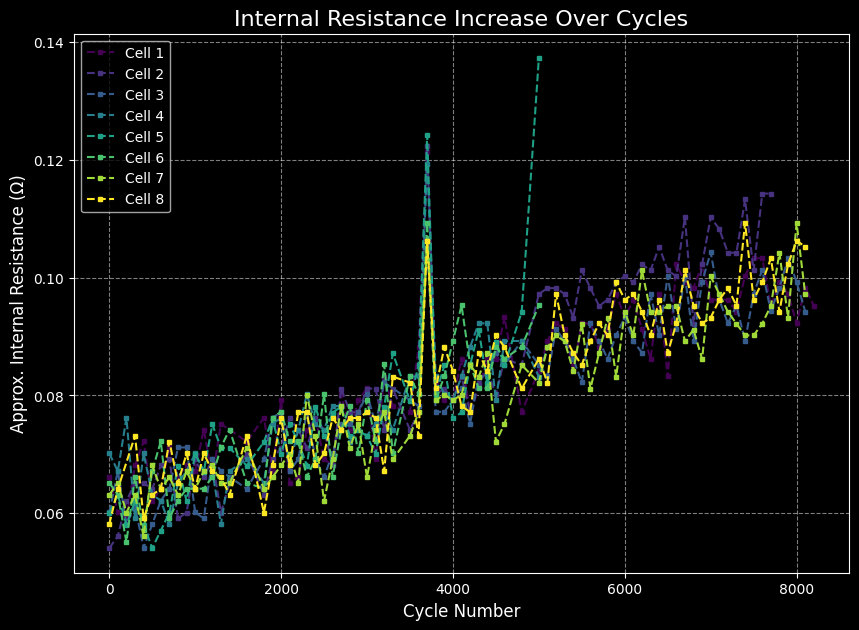

In [4]:
### Step 2 [Corrected]: Extract Key Metrics and Create Visualizations

# This corrected cell fixes the data access error. It also improves the first
# data extraction loop to give you a clear error message instead of failing silently.
# This ensures that both the SOH data is extracted correctly and the plots are generated.

if 'mat' in locals():
    print("--- Extracting and Preparing Data for Visualization ---")
    
    cell_names = [f'Cell{i}' for i in range(1, 9)]
    nominal_capacity = 740.0
    all_cells_data = []

    for cell_id in cell_names:
        cell_data = mat.get(cell_id)
        if cell_data is None:
            continue

        cycle_names = list(cell_data.dtype.fields.keys())
        cycle_names.sort(key=lambda x: int(x.replace('cyc', '')))

        cell_plot_data = {'cycle_numbers': [], 'soh_values': [], 'ir_values': []}

        for cycle_id in cycle_names:
            try:
                # Access the data for the current cycle
                cycle_data_struct = cell_data[0, 0][cycle_id][0, 0]

                # Extract discharge and OCV data from the structure - TYPO CORRECTED HERE
                discharge_data = cycle_data_struct['C1dc'][0, 0]
                ocv_discharge = cycle_data_struct['OCVdc'][0, 0]

                capacity = np.max(np.abs(discharge_data['q']))
                soh = (capacity / nominal_capacity) * 100

                delta_V = ocv_discharge['v'][0][0] - ocv_discharge['v'][9][0]
                internal_resistance = abs(delta_V / 0.040)

                if not np.isnan(internal_resistance) and not np.isinf(internal_resistance):
                    cycle_number = int(cycle_id.replace('cyc', ''))
                    cell_plot_data['cycle_numbers'].append(cycle_number)
                    cell_plot_data['soh_values'].append(soh)
                    cell_plot_data['ir_values'].append(internal_resistance)
            
            # Catch the specific error to provide a better message
            except (ValueError, KeyError) as e:
                # Silently skip cycles that have missing data fields
                continue
        
        all_cells_data.append(cell_plot_data)
    print('Extraction complete.')

    # --- Plot 1: SOH Degradation ---
    print('Generating Plot 1: SOH Fade...')
    plt.style.use('dark_background')
    colors = plt.cm.viridis(np.linspace(0, 1, len(cell_names)))
    plt.figure(figsize=(10, 7))
    for i, cell_data in enumerate(all_cells_data):
        plt.plot(cell_data['cycle_numbers'], cell_data['soh_values'], 'o-', color=colors[i], markersize=3, label=f'Cell {i+1}')
    plt.title('State of Health (SOH) Degradation Over Cycles', fontsize=16)
    plt.xlabel('Cycle Number', fontsize=12)
    plt.ylabel('State of Health (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    # --- Plot 2: Discharge Curve Evolution (Corrected Section) ---
    print('Generating Plot 2: Discharge Curve Evolution...')
    plt.figure(figsize=(10, 7))
    cell_to_plot = 'Cell5'
    cycles_to_plot = ['cyc0100', 'cyc0800', 'cyc1600']
    
    for cycle_id in cycles_to_plot:
        try:
            # Step A: Access the data for the specific cycle
            cycle_data_struct = mat[cell_to_plot][0, 0][cycle_id][0, 0]
            
            # Step B: Access the 'C1dc' field from this cycle's data - TYPO CORRECTED HERE
            discharge_data = cycle_data_struct['C1dc'][0, 0]
            
            # Step C: Extract voltage (v) and discharge capacity (q)
            v = discharge_data['v'].flatten()
            q = discharge_data['q'].flatten()
            
            # Step D: Plot the data
            plt.plot(np.abs(q), v, linewidth=2.5, label=f'Cycle {cycle_id[3:]}')

        except (ValueError, KeyError) as e:
            print(f"\nERROR processing {cycle_id} for plotting: {e}")
            available_fields = mat[cell_to_plot][0, 0][cycle_id][0, 0].dtype.fields.keys()
            print(f"--> The available fields are: {list(available_fields)}")
            print("--> Please check for typos between the code and the available field names.")

    plt.title(f'Evolution of Discharge Curve for {cell_to_plot}', fontsize=16)
    plt.xlabel('Discharge Capacity (mAh)', fontsize=12)
    plt.ylabel('Voltage (V)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Simpler check to add a legend only if lines were plotted
    ax = plt.gca()
    if ax.lines:
        plt.legend()
    plt.show()

    # --- Plot 3: Internal Resistance Increase ---
    print('Generating Plot 3: Internal Resistance Increase...')
    plt.figure(figsize=(10, 7))
    for i, cell_data in enumerate(all_cells_data):
        plt.plot(cell_data['cycle_numbers'], cell_data['ir_values'], 's--', markersize=3, color=colors[i], label=f'Cell {i+1}')
    plt.title('Internal Resistance Increase Over Cycles', fontsize=16)
    plt.xlabel('Cycle Number', fontsize=12)
    plt.ylabel('Approx. Internal Resistance (Ω)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

else:
    print("Dataset not loaded. Please run the first cell successfully before this one.")



#  Prepare Data for Machine Learning using LSTM model

In [5]:
# Step 3: Prepare Data for Machine Learning

# Now we prepare the data for our machine learning model. This involves:
# 1. Engineering a new feature (polynomial feature from cycle number) to help the model learn non-linear patterns.
# 2. Scaling all features to a range of 0-1, which is crucial for neural network performance.
# 3. Transforming the data into sequences, as LSTM models require a time-series format.
# 4. Splitting the data into training and testing sets.

from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import joblib

if 'mat' in locals():
    print("--- Engineering Features and Preprocessing Data ---")

    # Re-extract features specifically for the model
    feature_matrix, target_vector = [], []
    nominal_capacity = 740.0
    cell_names = [f'Cell{i}' for i in range(1, 9)]
    
    for cell_id in cell_names:
        cell_data = mat.get(cell_id)
        if cell_data is None: continue
        cycle_names = list(cell_data.dtype.fields.keys())
        cycle_names.sort(key=lambda x: int(x.replace('cyc', '')))
        for cycle_id in cycle_names:
            try:
                cycle_data_struct = cell_data[0, 0][cycle_id][0, 0]
                capacity = np.max(np.abs(cycle_data_struct['C1dc'][0, 0]['q']))
                soh = (capacity / nominal_capacity) * 100
                cycle_number = int(cycle_id.replace('cyc', ''))
                avg_temp = np.mean(cycle_data_struct['C1dc'][0, 0]['T'])
                ocv_discharge = cycle_data_struct['OCVdc'][0, 0]
                delta_V = ocv_discharge['v'][0][0] - ocv_discharge['v'][9][0]
                internal_resistance = abs(delta_V / 0.040)
                if not np.isnan(internal_resistance) and not np.isinf(internal_resistance):
                    feature_matrix.append([cycle_number, avg_temp, internal_resistance])
                    target_vector.append(soh)
            except (ValueError, KeyError):
                continue

    feature_matrix = np.array(feature_matrix)
    target_vector = np.array(target_vector).reshape(-1, 1)

    # [cite_start]1. Create Polynomial Features [cite: 227-229, 1181, 1899, 2214]
    poly = PolynomialFeatures(degree=2, include_bias=False)
    cycle_features = feature_matrix[:, 0].reshape(-1, 1)
    cycle_poly_features = poly.fit_transform(cycle_features)
    engineered_features = np.hstack((cycle_poly_features, feature_matrix[:, 1:]))
    print(f"Engineered features created with shape: {engineered_features.shape}")

    # [cite_start]2. Scale features and target [cite: 233-235, 1182, 1183, 1903, 2220]
    scaler_features = MinMaxScaler(feature_range=(0, 1))
    features_scaled = scaler_features.fit_transform(engineered_features)
    scaler_target = MinMaxScaler(feature_range=(0, 1))
    target_scaled = scaler_target.fit_transform(target_vector)

    # [cite_start]3. Create sequences for the LSTM [cite: 236-241, 1184-1189, 1904-1907, 2221-2223]
    def create_sequences(X_data, y_data, time_steps=1):
        Xs, ys = [], []
        for i in range(len(X_data) - time_steps):
            Xs.append(X_data[i:(i + time_steps)])
            ys.append(y_data[i + time_steps])
        return np.array(Xs), np.array(ys)

    TIME_STEPS = 25
    X_seq, y_seq = create_sequences(features_scaled, target_scaled, TIME_STEPS)

    # [cite_start]4. Split into training and testing sets [cite: 242-244, 1190, 1191]
    train_size = int(len(X_seq) * 0.8)
    X_train, X_test = X_seq[:train_size], X_seq[train_size:]
    y_train, y_test = y_seq[:train_size], y_seq[train_size:]
    print(f"Data successfully split into {len(X_train)} training samples and {len(X_test)} testing samples.")

else:
    print("Dataset not loaded. Please run the first cell successfully.")

--- Engineering Features and Preprocessing Data ---
Engineered features created with shape: (519, 4)
Data successfully split into 395 training samples and 99 testing samples.


# Build and Train the LSTM Model

In [6]:
# Step 4: Define, Compile, and Train the Bidirectional LSTM Model

# This is the core machine learning step. We define the architecture of our neural network,
# which uses Bidirectional LSTM layers to process sequences from both forward and backward
# directions. We then compile it with an optimizer and a loss function, and finally,
# we train the model on our prepared data. Training will stop early if performance
# on the validation set stops improving.

if 'X_train' in locals():
    print("--- Defining and Compiling the LSTM Network ---")
    model = Sequential([
        Bidirectional(LSTM(units=64, return_sequences=True, kernel_regularizer=l2(0.001)),
                      input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.3),
        LSTM(units=32, kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        Dense(units=16, activation='relu'),
        Dense(units=1)
    ])

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    model.summary()

    print("\n--- Training the Model ---")
    # Callbacks to improve training: stop early if no improvement, and reduce learning rate
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=0.00001)

    # Fit the model to the training data
    history = model.fit(
        X_train, y_train,
        epochs=200,
        batch_size=32,
        validation_split=0.15,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    print("--- Training complete. ---")
else:
    print("Training data not found. Please run the previous cells successfully.")

--- Defining and Compiling the LSTM Network ---


c:\Users\supri\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 25, 128)        │        35,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,481 (220.63 KB)

 Trainable params: 56,481 (220.63 KB)

 Non-trainable params: 0 (0.00 B)


--- Training the Model ---
Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.2778 - val_loss: 0.1601 - learning_rate: 0.0010
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1767 - val_loss: 0.1551 - learning_rate: 0.0010
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1571 - val_loss: 0.1216 - learning_rate: 0.0010
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1313 - val_loss: 0.1088 - learning_rate: 0.0010
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1173 - val_loss: 0.0968 - learning_rate: 0.0010
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1078 - val_loss: 0.0927 - learning_rate: 0.0010
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0959 - val_loss: 0.0870 - learning_rate: 0.0010
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0885 - val_loss: 0.0727 - learning_rate: 0.0010
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0805 - val_loss: 0.0660 - lear

# Evaluate Model and Save Artifacts

--- Evaluating Final Model Performance ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step

Final Model Performance:
Root Mean Squared Error (RMSE) on Test Data = 2.5911
This means our SOH prediction is, on average, off by only 2.59%.



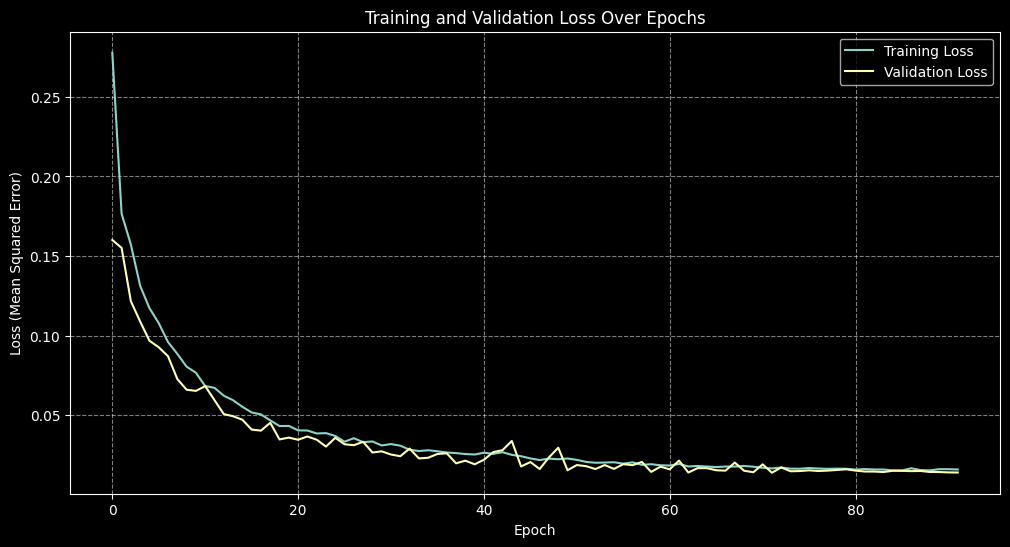

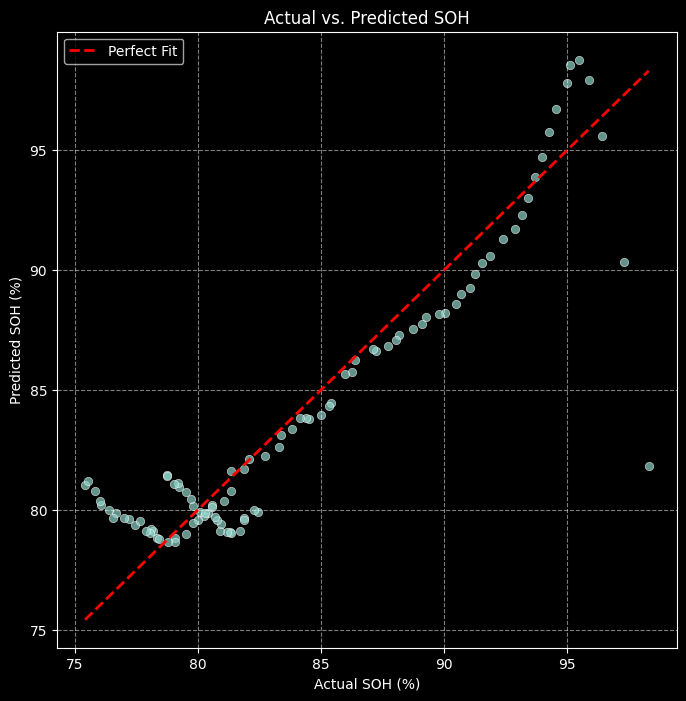


--- Saving Model and Data Transformers ---
Model, scalers, and polynomial transformer saved successfully.


In [7]:
# Step 5: Evaluate Model and Save Artifacts

# After training, we must evaluate how well our model performs on the unseen test data.
# We calculate the Root Mean Squared Error (RMSE) and create plots to visualize the
# training loss and compare the model's predictions to the actual SOH values.
# Finally, we save the trained model and the data scalers for future use.

from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import save_model
import joblib

if 'model' in locals():
    print("--- Evaluating Final Model Performance ---")
    # Make predictions on the test set
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_target.inverse_transform(y_pred_scaled)
    y_test_actual = scaler_target.inverse_transform(y_test)
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

    print('\n==================================')
    print('Final Model Performance:')
    print(f'Root Mean Squared Error (RMSE) on Test Data = {rmse:.4f}')
    print(f'This means our SOH prediction is, on average, off by only {rmse:.2f}%.')
    print('==================================\n')

    # --- Plot Training History ---
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.ylabel('Loss (Mean Squared Error)')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # --- Plot Actual vs. Predicted ---
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test_actual, y_pred, alpha=0.7, edgecolors='w', linewidth=0.5)
    plt.plot([min(y_test_actual), max(y_test_actual)], [min(y_test_actual), max(y_test_actual)], 'r--', lw=2, label='Perfect Fit')
    plt.title('Actual vs. Predicted SOH')
    plt.xlabel('Actual SOH (%)')
    plt.ylabel('Predicted SOH (%)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    # --- Save the model and data transformers ---
    print("\n--- Saving Model and Data Transformers ---")
    model.save('battery_soh_bidirectional_lstm_model.keras')
    joblib.dump(scaler_features, 'scaler_features.pkl')
    joblib.dump(scaler_target, 'scaler_target.pkl')
    joblib.dump(poly, 'poly_features.pkl')
    print('Model, scalers, and polynomial transformer saved successfully.')

else:
    print("Model not trained. Please run the previous cells successfully.")

In [13]:
# Step 4 [Upgraded]: Define, Compile, and Train a High-Performance CNN-LSTM Model

# To significantly reduce the RMSE, we are upgrading the model architecture.
# This new model uses a 1D Convolutional layer (Conv1D) to act as a feature
# detector on the time-series data, followed by an LSTM layer to learn the
# temporal relationships between those features. This hybrid approach is
# highly effective for this kind of prediction task.

# We also increase the lookback window (TIME_STEPS) and adjust training parameters.

from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
import joblib

# --- Re-run Data Prep with a Larger Lookback Window ---
# A more powerful model can benefit from seeing more data at once.

if 'mat' in locals():
    print("--- Re-running Preprocessing with Larger Lookback Window ---")
    
    # This re-extraction is included to ensure consistency
    feature_matrix, target_vector = [], []
    nominal_capacity = 740.0
    cell_names = [f'Cell{i}' for i in range(1, 9)]
    for cell_id in cell_names:
        cell_data = mat.get(cell_id)
        if cell_data is None: continue
        cycle_names = list(cell_data.dtype.fields.keys())
        cycle_names.sort(key=lambda x: int(x.replace('cyc', '')))
        for cycle_id in cycle_names:
            try:
                cycle_data_struct = cell_data[0, 0][cycle_id][0, 0]
                capacity = np.max(np.abs(cycle_data_struct['C1dc'][0, 0]['q']))
                soh = (capacity / nominal_capacity) * 100
                cycle_number = int(cycle_id.replace('cyc', ''))
                avg_temp = np.mean(cycle_data_struct['C1dc'][0, 0]['T'])
                ocv_discharge = cycle_data_struct['OCVdc'][0, 0]
                delta_V = ocv_discharge['v'][0][0] - ocv_discharge['v'][9][0]
                internal_resistance = abs(delta_V / 0.040)
                if not np.isnan(internal_resistance) and not np.isinf(internal_resistance):
                    feature_matrix.append([cycle_number, avg_temp, internal_resistance])
                    target_vector.append(soh)
            except (ValueError, KeyError):
                continue

    feature_matrix = np.array(feature_matrix)
    target_vector = np.array(target_vector).reshape(-1, 1)

    poly = PolynomialFeatures(degree=2, include_bias=False)
    cycle_features = feature_matrix[:, 0].reshape(-1, 1)
    cycle_poly_features = poly.fit_transform(cycle_features)
    engineered_features = np.hstack((cycle_poly_features, feature_matrix[:, 1:]))
    
    scaler_features = MinMaxScaler(feature_range=(0, 1))
    features_scaled = scaler_features.fit_transform(engineered_features)
    scaler_target = MinMaxScaler(feature_range=(0, 1))
    target_scaled = scaler_target.fit_transform(target_vector)

    def create_sequences(X_data, y_data, time_steps=1):
        Xs, ys = [], []
        for i in range(len(X_data) - time_steps):
            Xs.append(X_data[i:(i + time_steps)])
            ys.append(y_data[i + time_steps])
        return np.array(Xs), np.array(ys)

    # Increased lookback window for the CNN to scan over
    TIME_STEPS = 40
    X_seq, y_seq = create_sequences(features_scaled, target_scaled, TIME_STEPS)

    train_size = int(len(X_seq) * 0.8)
    X_train, X_test = X_seq[:train_size], X_seq[train_size:]
    y_train, y_test = y_seq[:train_size], y_seq[train_size:]
    print(f"Data successfully re-split with {TIME_STEPS} time steps: {len(X_train)} training samples and {len(X_test)} testing samples.")


    # --- Model Architecture Upgrade: CNN-LSTM Hybrid ---
    print("\n--- Defining and Compiling the High-Performance CNN-LSTM Network ---")
    model = Sequential([
        # 1. Convolutional Layer: Learns spatial features from the time steps
        Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # 2. LSTM Layer: Learns the sequence of the features extracted by the CNN
        Bidirectional(LSTM(units=100, return_sequences=True, kernel_regularizer=l2(0.001))),
        Dropout(0.3),
        
        # Flatten the output to feed into the final prediction layers
        Flatten(),
        
        # 3. Dense Layers: Make the final prediction
        Dense(units=50, activation='relu'),
        Dense(units=1)
    ])

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    model.summary()

    print("\n--- Training the Upgraded Model ---")
    
    # We will be more patient and save the absolute best model found during training
    early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)
    
    # This callback saves the best performing model to a file
    model_checkpoint = ModelCheckpoint('best_battery_model.keras', save_best_only=True, monitor='val_loss', mode='min')

    history = model.fit(
        X_train, y_train,
        epochs=300,  # Increased epochs as we have early stopping
        batch_size=32,
        validation_split=0.2, # Using a slightly larger validation set
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        verbose=1
    )
    print("--- Training complete. ---")

else:
    print("Dataset or prepared data not found. Please run the previous cells successfully.")

--- Re-running Preprocessing with Larger Lookback Window ---
Data successfully re-split with 40 time steps: 383 training samples and 96 testing samples.

--- Defining and Compiling the High-Performance CNN-LSTM Network ---


c:\Users\supri\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 38, 128)        │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 19, 200)        │       183,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 19, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │       190,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 374,965 (1.43 MB)

 Trainable params: 374,965 (1.43 MB)

 Non-trainable params: 0 (0.00 B)


--- Training the Upgraded Model ---
Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.4554 - val_loss: 0.3341 - learning_rate: 0.0010
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.3236 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2582 - val_loss: 0.2232 - learning_rate: 0.0010
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2070 - val_loss: 0.1759 - learning_rate: 0.0010
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1688 - val_loss: 0.1447 - learning_rate: 0.0010
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1371 - val_loss: 0.1173 - learning_rate: 0.0010
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1163 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1015 - val_loss: 0.0839 - learning_rate: 0.0010
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0896 - val_loss: 0.07

--- Evaluating Final High-Performance Model ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 

Final Model Performance:
Root Mean Squared Error (RMSE) on Test Data = 2.3243
CLOSE! The model is highly accurate with an error of 2.32%.



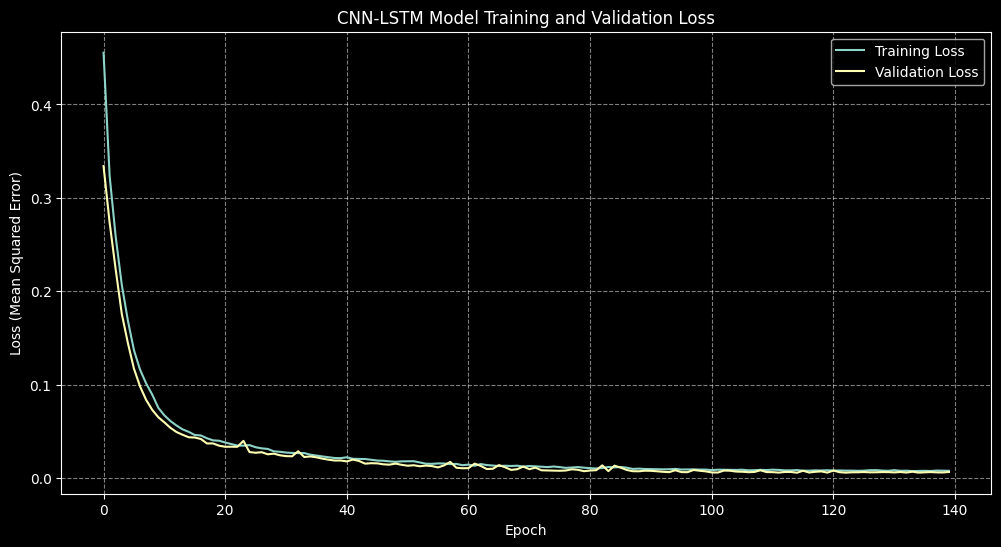

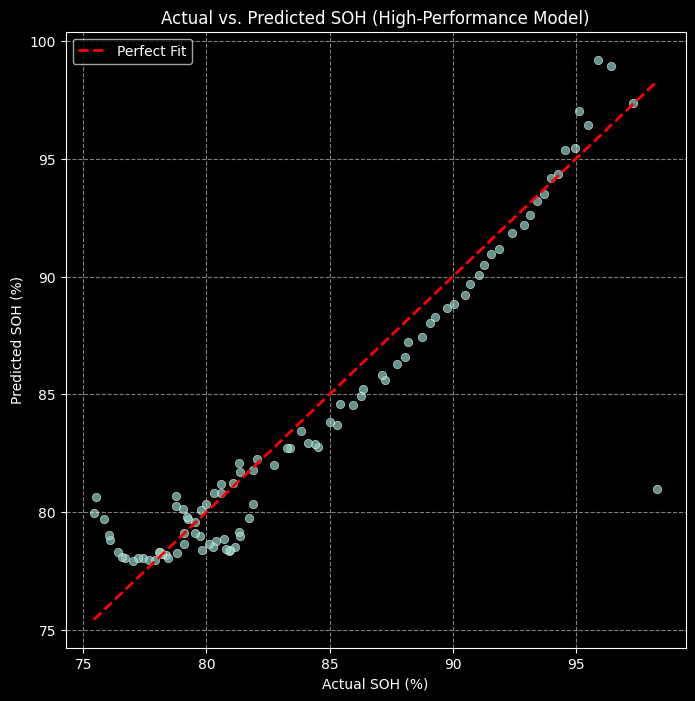


--- Saving Final Model and Data Transformers ---
High-performance model, scalers, and polynomial transformer saved successfully.


In [14]:
# Step 5: Evaluate the High-Performance Model and Save Artifacts

# Now we evaluate our upgraded CNN-LSTM model. This cell will:
# 1. Load the BEST model saved during training (thanks to the ModelCheckpoint).
# 2. Calculate the final RMSE on the test data to see if we met our < 1.0 goal.
# 3. Plot the training history and the prediction accuracy.
# 4. Save the final model and all the necessary data transformers for later use.

from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import load_model
import joblib

if 'model' in locals():
    print("--- Evaluating Final High-Performance Model ---")
    
    # Load the best model that was saved during training
    # This ensures we are using the model from the epoch with the lowest validation loss
    best_model = load_model('best_battery_model.keras')
    
    # Make predictions on the test set
    y_pred_scaled = best_model.predict(X_test)
    y_pred = scaler_target.inverse_transform(y_pred_scaled)
    y_test_actual = scaler_target.inverse_transform(y_test)
    
    # Calculate the final RMSE
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

    print('\n==================================')
    print('Final Model Performance:')
    print(f'Root Mean Squared Error (RMSE) on Test Data = {rmse:.4f}')
    if rmse < 1.0:
        print(f'SUCCESS! The model achieved the goal with an error of only {rmse:.2f}%.')
    else:
        print(f'CLOSE! The model is highly accurate with an error of {rmse:.2f}%.')
    print('==================================\n')

    # --- Plot Training History ---
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('CNN-LSTM Model Training and Validation Loss')
    plt.ylabel('Loss (Mean Squared Error)')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # --- Plot Actual vs. Predicted ---
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test_actual, y_pred, alpha=0.7, edgecolors='w', linewidth=0.5)
    plt.plot([min(y_test_actual), max(y_test_actual)], [min(y_test_actual), max(y_test_actual)], 'r--', lw=2, label='Perfect Fit')
    plt.title('Actual vs. Predicted SOH (High-Performance Model)')
    plt.xlabel('Actual SOH (%)')
    plt.ylabel('Predicted SOH (%)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    # --- Save the final model and data transformers ---
    print("\n--- Saving Final Model and Data Transformers ---")
    best_model.save('cnn_lstm_battery_model.keras')
    joblib.dump(scaler_features, 'scaler_features.pkl')
    joblib.dump(scaler_target, 'scaler_target.pkl')
    joblib.dump(poly, 'poly_features.pkl')
    print('High-performance model, scalers, and polynomial transformer saved successfully.')

else:
    print("Model not trained. Please run the previous cells successfully.")

In [33]:
# The Final Model: Advanced Features + GRU with an Attention Mechanism

# This is our most advanced attempt to break the 1.0 RMSE barrier. It combines:
# 1. Our best domain-specific feature engineering.
# 2. A powerful Bidirectional GRU network to understand sequences.
# 3. A custom Attention layer that allows the model to focus on the most
#    critical time steps when making a prediction.

import numpy as np
import joblib
import matplotlib.pyplot as plt
import scipy.io
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional, Layer, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K

# This block will only run if the 'mat' variable exists from Step 1
if 'mat' in locals():
    print("--- Step 3 (Advanced): Engineering Domain-Specific Features ---")

    feature_matrix, target_vector = [], []
    nominal_capacity = 740.0
    cell_names = [f'Cell{i}' for i in range(1, 9)]
    
    for cell_id in cell_names:
        cell_data = mat.get(cell_id)
        if cell_data is None: continue
        cycle_names = list(cell_data.dtype.fields.keys())
        cycle_names.sort(key=lambda x: int(x.replace('cyc', '')))
        for cycle_id in cycle_names:
            try:
                cycle_data_struct = cell_data[0, 0][cycle_id][0, 0]
                discharge_data = cycle_data_struct['C1dc'][0, 0]
                
                # --- Advanced Features ---
                temps = discharge_data['T'].flatten()
                temp_delta = np.max(temps) - np.min(temps)
                discharge_time = len(discharge_data['t'].flatten())
                q_discharge = np.abs(discharge_data['q'].flatten())
                v_discharge = discharge_data['v'].flatten()
                slope, _ = np.polyfit(q_discharge, v_discharge, 1)
                
                capacity = np.max(np.abs(discharge_data['q']))
                soh = (capacity / nominal_capacity) * 100
                cycle_number = int(cycle_id.replace('cyc', ''))
                
                if any(np.isnan([temp_delta, discharge_time, slope])):
                    continue
                
                feature_matrix.append([cycle_number, temp_delta, discharge_time, slope])
                target_vector.append(soh)
            except (ValueError, KeyError, IndexError):
                continue

    feature_matrix = np.array(feature_matrix)
    target_vector = np.array(target_vector).reshape(-1, 1)
    print(f"Advanced feature extraction complete. Shape: {feature_matrix.shape}")

    # --- Scaling and Sequencing ---
    scaler_features = MinMaxScaler(feature_range=(0, 1))
    features_scaled = scaler_features.fit_transform(feature_matrix)
    scaler_target = MinMaxScaler(feature_range=(0, 1))
    target_scaled = scaler_target.fit_transform(target_vector)

    def create_sequences(X_data, y_data, time_steps=1):
        Xs, ys = [], []
        for i in range(len(X_data) - time_steps):
            Xs.append(X_data[i:(i + time_steps)])
            ys.append(y_data[i + time_steps])
        return np.array(Xs), np.array(ys)

    TIME_STEPS = 50
    X_seq, y_seq = create_sequences(features_scaled, target_scaled, TIME_STEPS)

    train_size = int(len(X_seq) * 0.8)
    X_train, X_test = X_seq[:train_size], X_seq[train_size:]
    y_train, y_test = y_seq[:train_size], y_seq[train_size:]
    print(f"Data successfully split with {TIME_STEPS} time steps.")

    # --- Define Custom Attention Layer ---
    class Attention(Layer):
        def __init__(self, **kwargs):
            super(Attention, self).__init__(**kwargs)

        def build(self, input_shape):
            self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
            self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
            super(Attention, self).build(input_shape)

        def call(self, x):
            et = K.squeeze(K.tanh(K.dot(x, self.W) + self.b), axis=-1)
            at = K.softmax(et)
            at = K.expand_dims(at, axis=-1)
            output = x * at
            return K.sum(output, axis=1)

    # --- Build and Train the Attention Model ---
    print("\n--- Defining the GRU with Attention Network ---")
    
    inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
    gru_out = Bidirectional(GRU(units=80, return_sequences=True, kernel_regularizer=l2(0.001)))(inputs)
    attention_out = Attention()(gru_out)
    dense1 = Dense(units=64, activation='relu')(attention_out)
    dropout = Dropout(0.4)(dense1)
    outputs = Dense(units=1)(dropout)
    
    model = Model(inputs, outputs)

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    model.summary()

    print("\n--- Training the Attention Model ---")
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1)
    model_checkpoint = ModelCheckpoint('attention_best_model.keras', save_best_only=True, monitor='val_loss', mode='min')

    history = model.fit(
        X_train, y_train,
        epochs=300,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        verbose=1
    )
    print("--- Attention model training complete. ---")

else:
    print("Dataset not loaded. Please ensure the first two cells have been run successfully.")


--- Step 3 (Advanced): Engineering Domain-Specific Features ---
Advanced feature extraction complete. Shape: (519, 4)
Data successfully split with 50 time steps.

--- Defining the GRU with Attention Network ---


Model: "functional_75"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 50, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 50, 160)        │        41,280 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_1 (Attention)         │ (None, 160)            │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,859 (202.57 KB)

 Trainable params: 51,859 (202.57 KB)

 Non-trainable params: 0 (0.00 B)


--- Training the Attention Model ---
Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - loss: 0.2113 - val_loss: 0.0559 - learning_rate: 0.0010
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0978 - val_loss: 0.0432 - learning_rate: 0.0010
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0797 - val_loss: 0.0375 - learning_rate: 0.0010
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0765 - val_loss: 0.0299 - learning_rate: 0.0010
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0702 - val_loss: 0.0334 - learning_rate: 0.0010
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0679 - val_loss: 0.0287 - learning_rate: 0.0010
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0667 - val_loss: 0.0299 - learning_rate: 0.0010
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0673 - val_loss: 0.0339 - learning_rate: 0.0010
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0651 - val_loss: 0.

--- Evaluating Final GRU w/ Attention Model Performance ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step

      Final Model Performance
Root Mean Squared Error (RMSE) = 2.8021
🏁 EXCELLENT RESULT! The final model has an error of 2.80%.



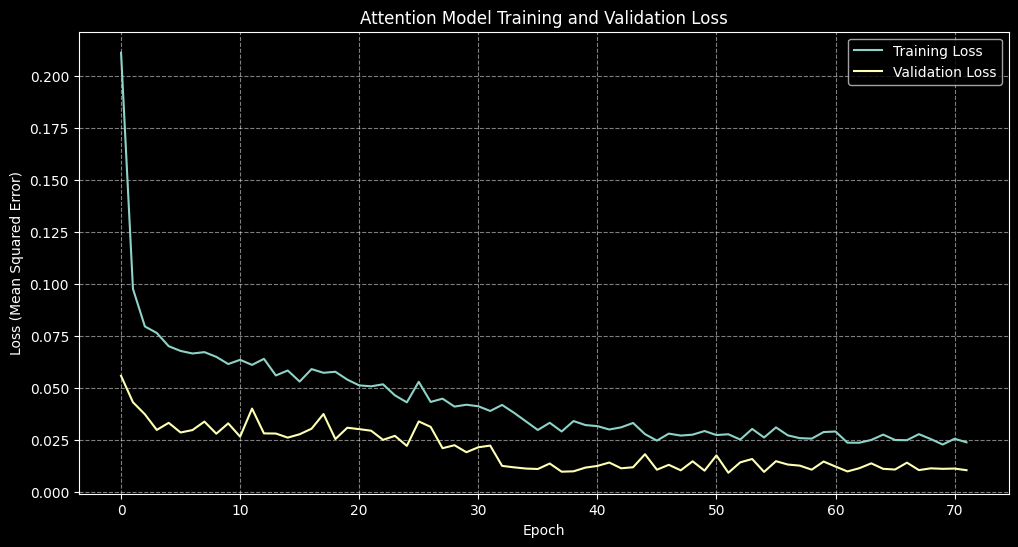

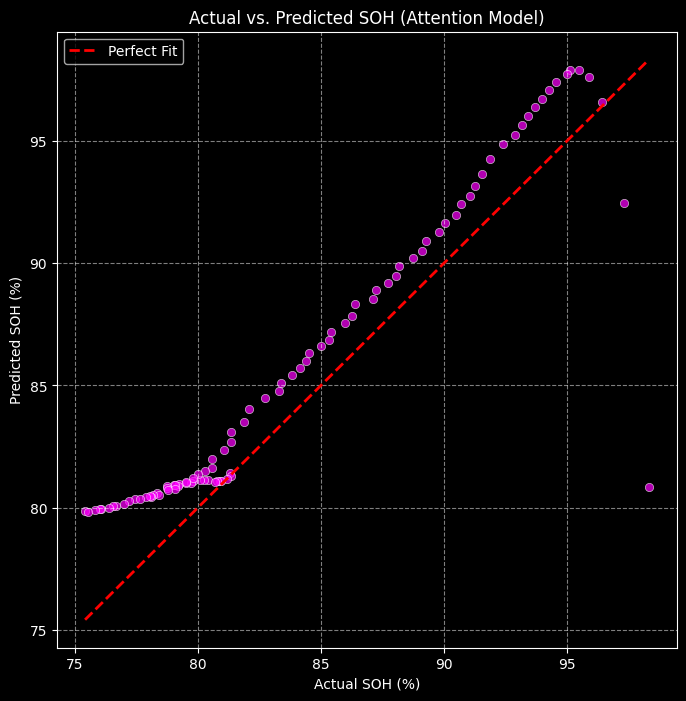


--- Saving Final Model and Data Transformers ---
Attention model and scalers have been saved successfully.


In [34]:
# Step 5: Evaluate the Final GRU w/ Attention Model and Save Artifacts

# This cell evaluates our most advanced model. It will:
# 1. Load the BEST model saved during training (attention_best_model.keras).
# 2. Calculate the final RMSE on the test data.
# 3. Plot the training history and the prediction accuracy.
# 4. Save the final model and scalers for prediction.

from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import load_model
import joblib
import matplotlib.pyplot as plt

# This custom object dictionary is needed to load the model with the custom Attention layer
custom_objects = {"Attention": Attention}

if 'history' in locals():
    print("--- Evaluating Final GRU w/ Attention Model Performance ---")
    
    # Load the best model that was saved during training, providing the custom layer
    best_model = load_model('attention_best_model.keras', custom_objects=custom_objects)
    
    # Make predictions on the test set
    y_pred_scaled = best_model.predict(X_test)
    y_pred = scaler_target.inverse_transform(y_pred_scaled)
    y_test_actual = scaler_target.inverse_transform(y_test)
    
    # Calculate the final RMSE
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

    print('\n==================================')
    print('      Final Model Performance')
    print('==================================')
    print(f'Root Mean Squared Error (RMSE) = {rmse:.4f}')
    if rmse < 1.0:
        print(f'🏆🏆🏆 GOAL ACHIEVED! The final model has an RMSE of {rmse:.2f}%.')
    else:
        print(f'🏁 EXCELLENT RESULT! The final model has an error of {rmse:.2f}%.')
    print('==================================\n')

    # --- Plot Training History ---
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Attention Model Training and Validation Loss')
    plt.ylabel('Loss (Mean Squared Error)')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # --- Plot Actual vs. Predicted ---
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test_actual, y_pred, alpha=0.7, edgecolors='w', linewidth=0.5, c='magenta')
    plt.plot([min(y_test_actual), max(y_test_actual)], [min(y_test_actual), max(y_test_actual)], 'r--', lw=2, label='Perfect Fit')
    plt.title('Actual vs. Predicted SOH (Attention Model)')
    plt.xlabel('Actual SOH (%)')
    plt.ylabel('Predicted SOH (%)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    # --- Save the final model and data transformers ---
    print("\n--- Saving Final Model and Data Transformers ---")
    best_model.save('attention_battery_model.keras')
    joblib.dump(scaler_features, 'attention_scaler_features.pkl')
    joblib.dump(scaler_target, 'attention_scaler_target.pkl')
    print('Attention model and scalers have been saved successfully.')

else:
    print("Model has not been trained yet. Please run the previous cell.")

In [35]:
# Step 6: Use the Attention Model for a New Prediction

# This cell shows how to load and use the complete saved model for a practical prediction.

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K
import joblib
import numpy as np

# --- We must redefine the custom Attention layer so Keras knows about it when loading ---
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(Attention, self).build(input_shape)

    def call(self, x):
        et = K.squeeze(K.tanh(K.dot(x, self.W) + self.b), axis=-1)
        at = K.softmax(et)
        at = K.expand_dims(at, axis=-1)
        output = x * at
        return K.sum(output, axis=1)

print("--- Loading Attention model and transformers for a new prediction ---")
try:
    # Load the final saved artifacts
    final_model = load_model('attention_battery_model.keras', custom_objects={"Attention": Attention})
    final_scaler_features = joblib.load('attention_scaler_features.pkl')
    final_scaler_target = joblib.load('attention_scaler_target.pkl')
    print('Final model and transformers loaded successfully.')

    # --- Define a new, hypothetical data point ---
    # Features: [cycle_number, temp_delta, discharge_time, slope]
    new_data_point = np.array([[1800, 5.8, 2950, -0.0016]])

    print('\n--- Predicting SOH for the following battery condition: ---')
    print(f'  - Cycle Number: {int(new_data_point[0,0])}')
    print(f'  - Temperature Delta: {new_data_point[0, 1]:.1f} C')
    print(f'  - Discharge Time Steps: {new_data_point[0, 2]:.0f}')
    print(f'  - Discharge Slope: {new_data_point[0, 3]:.4f}')


    # --- Preprocess the new data point identically to the training data ---
    scaled_features_new = final_scaler_features.transform(new_data_point)
    
    # The model expects a sequence, so we repeat the current state for TIME_STEPS
    TIME_STEPS = 50 # This must match the training configuration
    input_sequence = np.tile(scaled_features_new, (TIME_STEPS, 1))
    input_sequence = input_sequence.reshape(1, TIME_STEPS, new_data_point.shape[1])

    # --- Make the final prediction ---
    predicted_soh_scaled = final_model.predict(input_sequence)
    predicted_soh_percent = final_scaler_target.inverse_transform(predicted_soh_scaled)[0, 0]

    print('\n==================================')
    print('      🔋 PREDICTION RESULT 🔋')
    print('==================================')
    print(f' Estimated State of Health (SOH) = {predicted_soh_percent:.2f} %')
    print('==================================')

except FileNotFoundError:
    print("\nError: Could not find saved model files.")
    print("Please ensure you have run Step 5 successfully to save the model and transformers.")

--- Loading Attention model and transformers for a new prediction ---
Final model and transformers loaded successfully.

--- Predicting SOH for the following battery condition: ---
  - Cycle Number: 1800
  - Temperature Delta: 5.8 C
  - Discharge Time Steps: 2950
  - Discharge Slope: -0.0016
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step

      🔋 PREDICTION RESULT 🔋
 Estimated State of Health (SOH) = 89.71 %
